[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA_baseline.ipynb)

##NCA BASELINE

We follow the principal concept of Distill NCA with the same pool sampling mechanism, update rule and loss function


In [2]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 475, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 475 (delta 74), reused 43 (delta 20), pack-reused 322 (from 1)
Receiving objects: 100% (475/475), 22.02 MiB | 13.81 MiB/s, done.
Resolving deltas: 100% (259/259), done.
Success! Files now found: ['utils.py', 'NCA_baseline.py', '.git', 'Images', 'pathway.py', 'EBM_NCA_baseline.ipynb', 'EBM_NCA.ipynb', 'README.md', 'NCA.py']


In [3]:

#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA_baseline import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [4]:
#@title Setup { vertical-output: true}
HEIGHT = 35 #@param {type:"integer"}
WIDTH = 35 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8500  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [5]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING


In [6]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

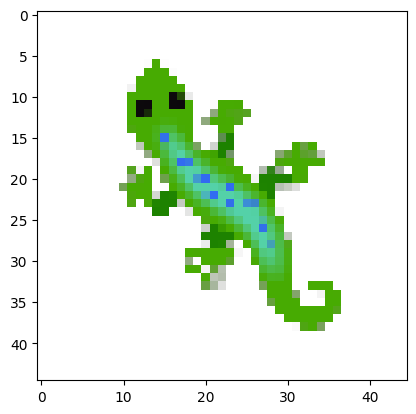

In [7]:
#@title Display Primitives { vertical-output: true}

def make_seed(size, channels=16):
    x = np.zeros([channels, size, size], dtype=np.float32)
    x[3:, size // 2, size // 2] = 1.0
    return x

seed = make_seed(HEIGHT, CHANNELS)

pool_inputs = np.repeat(seed[None, ...], POOL_SIZE, axis=0)
pool = SamplePool(x=pool_inputs)


plt.imshow(image_to_display)
plt.show()


In [8]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [9]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [10]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene created


In [11]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = NCA(CHANNELS,HIDDEN_SIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

In [12]:
def create_circular_mask(image_size, center_x, center_y, radius, device="cuda:0"):
    height, width = HEIGHT, WIDTH
    y_grid, x_grid = torch.meshgrid(
        torch.arange(height, device=device),
        torch.arange(width, device=device),
        indexing='ij'
    )
    distance_squared = (x_grid - center_x) ** 2 + (y_grid - center_y) ** 2
    return distance_squared <= (radius ** 2)

/tmp/ipykernel_10876/4243651219.py:129: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 4))


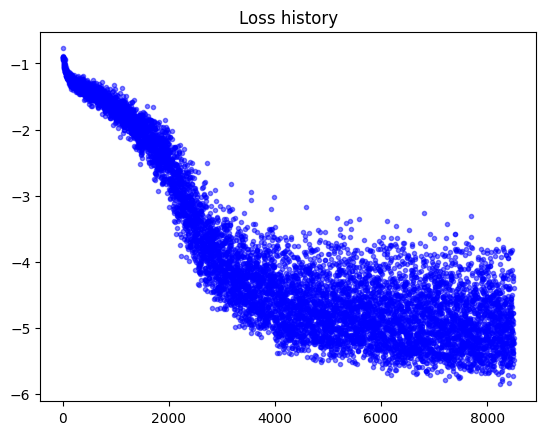

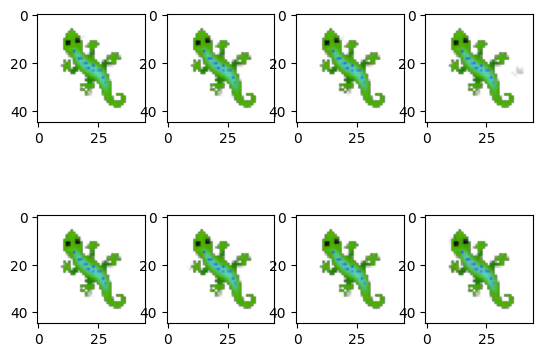

In [ ]:
#@title Training { vertical-output: true}

DAMAGE_N = 3
PCA_REFIT_EVERY = 500
LOG_HIDDEN_EVERY = 100

hidden_layers = []
hidden_corr = []
hidden_layers_iters = []
pca_maps = []
pca = None
loss_log = []

for i in range(TRAINING_ITERS + 1):
    # 1. Pool Sampling & Manipulation
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x0_np = batch.x.copy()  # Shape: (BATCH_SIZE, C, H, W)

        # A. Rank samples directly on CPU using lightweight NumPy operations
        # Avoids unnecessary early GPU memory allocations
        x0_tensor = torch.from_numpy(x0_np).to(DEVICE)
        pre_pixel_loss = (x0_tensor[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])

        # Sort indices (descending: highest loss first)
        loss_rank = pre_pixel_loss.cpu().numpy().argsort()[::-1]

        # Re-order x0_np AND align pool slot indices so write-back stays consistent
        x0_np = x0_np[loss_rank]
        if hasattr(batch, 'indices'):
            batch.indices = batch.indices[loss_rank]

        # B. Replace highest-loss sample (index 0) with fresh seed
        seed_np = seed.detach().cpu().numpy() if isinstance(seed, torch.Tensor) else seed.copy()
        if seed_np.ndim == 4:
            seed_np = seed_np[0]
        if seed_np.shape[-1] == CHANNELS and seed_np.shape[0] != CHANNELS:
            seed_np = seed_np.transpose(2, 0, 1)  # Ensure (C, H, W) order

        x0_np[0] = seed_np

        # C. Apply damage to the BEST performing samples (lowest loss at the end of sorted array)
        if DAMAGE_N > 0:
            for idx in range(1, DAMAGE_N + 1):
                cx = random.randint(int(WIDTH * 0.2), int(WIDTH * 0.8))
                cy = random.randint(int(HEIGHT * 0.2), int(HEIGHT * 0.8))
                r = random.randint(4, 10)

                mask_np = create_circular_mask(HEIGHT, cx, cy, radius=r).cpu().numpy().astype(np.float32)

                # Ensure mask matches (1, H, W) or (C, H, W) explicitly
                if mask_np.ndim == 2:
                    mask_np = mask_np[None, ...]  # Shape: (1, H, W)

                damage = 1.0 - mask_np
                x0_np[-idx] *= damage

        # Send fully prepared initial state to GPU
        x = torch.from_numpy(x0_np).to(DEVICE)

    # 2. Rollout loop
    steps = random.randrange(64, 94)
    for _ in range(steps):
        out = nca(x)
        x = out[0] if isinstance(out, tuple) else out

    # 3. Target Discrepancy & Loss
    pixel_loss = (x[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])
    edge_loss = (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).mean(dim=[1, 2, 3])

    per_sample_loss = pixel_loss + 0.5 * edge_loss
    loss = per_sample_loss.mean()

    # 4. Optimization step
    optim.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)
    optim.step()

    loss_log.append(loss.log().item())

    # 5. Commit rolled-out states back to pool
    with torch.no_grad():
        batch.x[:] = x.detach().cpu().numpy()
        batch.commit()

    scheduler.step()

    # 6. Correlation & PCA Tracking (Memory-Managed)
    with torch.no_grad():
        visible = x[:, :4, :, :]
        hidden = x[:, 4:16, :, :]

        B, n_vis, H, W = visible.shape
        n_hid = hidden.shape[1]

        v_flat = visible.permute(0, 2, 3, 1).reshape(-1, n_vis)
        h_flat = hidden.permute(0, 2, 3, 1).reshape(-1, n_hid)

        living_mask = v_flat[:, 3] > 0.1

        if living_mask.sum() < 10:
            hidden_corr.append(float('nan'))
        else:
            h_live = h_flat[living_mask].cpu().numpy()
            if n_hid > 1:
                cc_hh = np.abs(np.corrcoef(h_live, rowvar=False))
                hh_val = np.mean(cc_hh[np.triu_indices(n_hid, k=1)])
            else:
                hh_val = 0.0
            hidden_corr.append(hh_val)

            # Subsample 500 random pixels to prevent RAM bloat
            if i % LOG_HIDDEN_EVERY == 0:
                subsample_idx = np.random.choice(len(h_live), size=min(500, len(h_live)), replace=False)
                hidden_layers.append(h_live[subsample_idx])
                hidden_layers_iters.append(i)

        if i % PCA_REFIT_EVERY == 0 and len(hidden_layers) > 0:
            pooled = np.concatenate(hidden_layers[-20:], axis=0)  # Fit on last 20 logged snapshots
            pca = PCA(n_components=2)
            pca.fit(pooled)

    # 7. Visualization & Checkpointing
    if i % 100 == 0:
        print(f"Training iter {i}, loss = {loss.item():.5f}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        utils.show_batch(x[2:10])
        plt.show(block=False)
        plt.pause(0.01)

        display(HTML(style))
        torch.save(nca.state_dict(), f"Trained_models/{name}.pth")

    # 8. Store PCA projections
    if pca is not None and i % 10 == 0:
        with torch.no_grad():
            grid0_hidden = hidden[0]
            grid0_alive = (visible[0, 3] > 0.1).cpu().numpy()

            h_grid_flat = grid0_hidden.permute(1, 2, 0).reshape(-1, n_hid).detach().cpu().numpy()
            proj = pca.transform(h_grid_flat)
            PC1_map = proj[:, 0].reshape(H, W)
            PC2_map = proj[:, 1].reshape(H, W)

            pca_maps.append((i, PC1_map, PC2_map, grid0_alive))

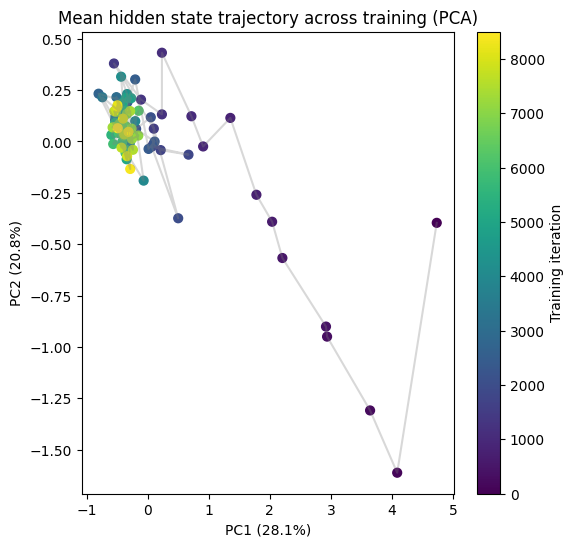

In [ ]:

pooled = np.concatenate(hidden_layers, axis=0)
pca = PCA(n_components=2)
pca.fit(pooled)

means, stds = [], []
for h_live in hidden_layers:
    proj = pca.transform(h_live)
    means.append(proj.mean(axis=0))
    stds.append(proj.std(axis=0))
means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(6, 6))
sc = plt.scatter(means[:, 0], means[:, 1], c=hidden_layers_iters, cmap='viridis', s=40)
plt.plot(means[:, 0], means[:, 1], alpha=0.3, color='gray')
plt.colorbar(sc, label="Training iteration")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Mean hidden state trajectory across training (PCA)")
plt.show()

In [13]:
del nca
del optim
torch.cuda.empty_cache()

In [14]:
nca = NCA(CHANNELS,hidden_n=HIDDEN_SIZE)
nca.load_state_dict(torch.load("Trained_models/Gene/NCA_baseline_correct_w_damage.pth"))
nca.to(DEVICE).eval()


NCA(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

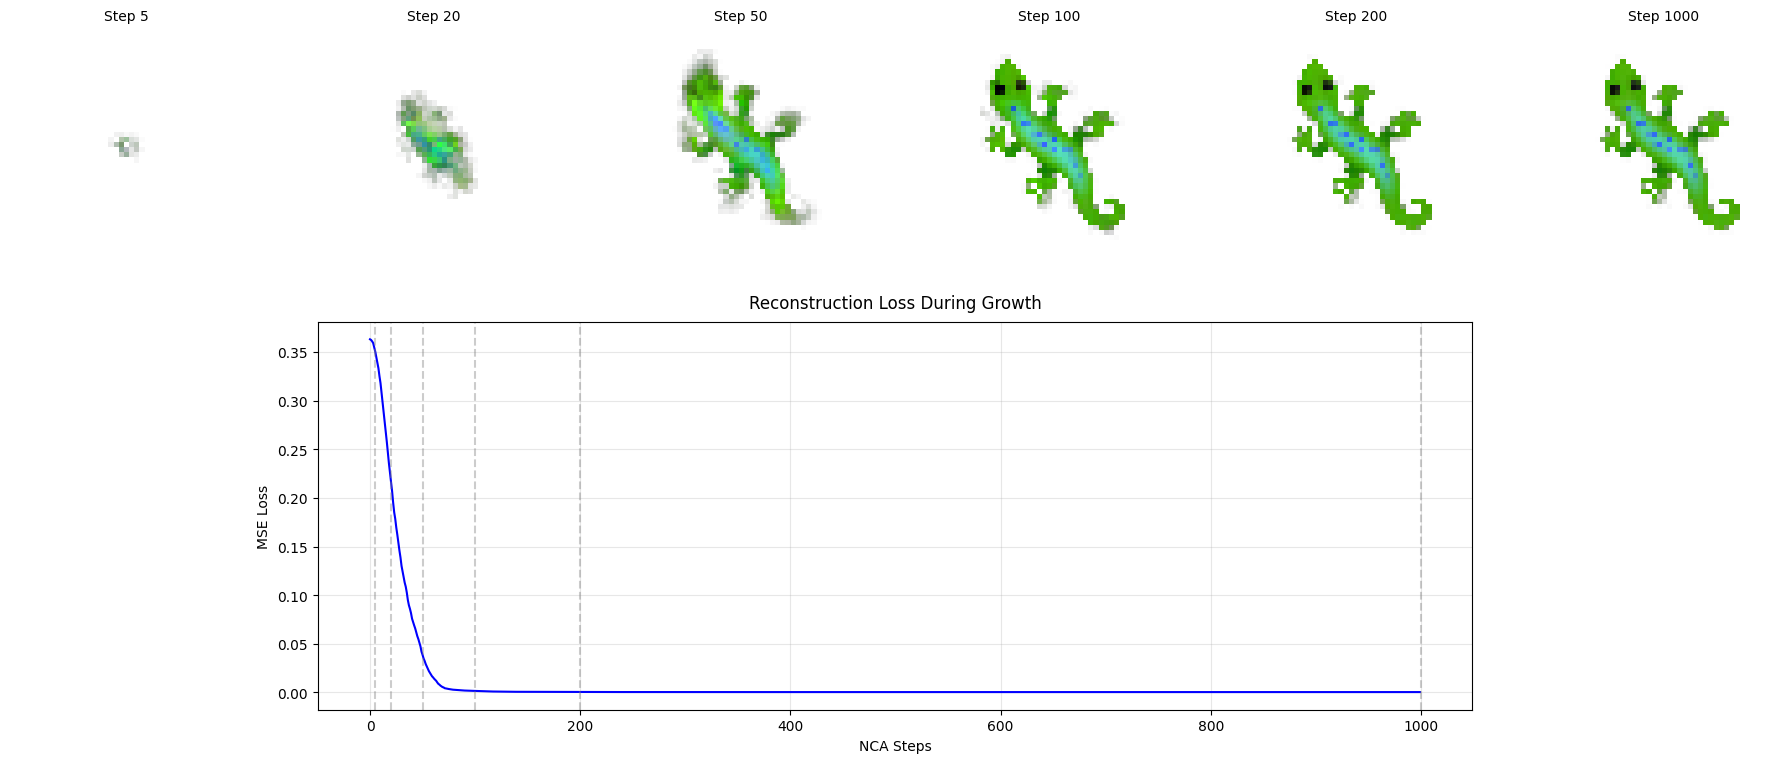

Time to grow: 85 steps


In [15]:
## Growing the morphology
def find_convergence_step(mse_sequence, patience=10, delta_tol=1e-4, target_mse=0.005):
    patience_counter = 0
    prev_mse = float('inf')

    for i, current_mse in enumerate(mse_sequence):
        delta_mse = abs(prev_mse - current_mse)
        if current_mse < target_mse and delta_mse < delta_tol:
            patience_counter += 1
        else:
            patience_counter = 0

        if patience_counter >= patience:
            return i - patience + 1

        prev_mse = current_mse

    return None


def visualize_growth(nca, seed, base, steps_to_show=[5, 20, 50, 100, 200, 1000]):
    x = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.clone().to(DEVICE)
    live_mask = (base[:, 3:4] > 0.1).float()

    total_steps = max(steps_to_show)
    mse_log = []       # dense, one entry per step — for convergence detection
    frames = []         # sparse, only at milestones — for the image grid

    with torch.no_grad():
        for t in range(1, total_steps + 1):
            x = nca(x)

            diff = (x[:, :4] - base) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
            mse_log.append(current_mse)

            if t in steps_to_show:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                frames.append(frame_img)

    # --- Image grid ---
    num_frames = len(steps_to_show)
    frame_titles = [f"Step {step}" for step in steps_to_show]
    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(2, num_frames, height_ratios=[1, 1.2])

    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    # --- Dense loss curve ---
    ax_loss = fig.add_subplot(gs[1, 1:num_frames - 1])
    ax_loss.plot(mse_log, color="blue", linewidth=1.5)
    ax_loss.set_title("Reconstruction Loss During Growth", fontsize=12, pad=10)
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)

    for t in steps_to_show:
        ax_loss.axvline(x=t, color="gray", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    growth_time = find_convergence_step(mse_log)
    if growth_time is None:
        print("Did not converge within the observed window")
    else:
        print(f"Time to grow: {growth_time} steps")


visualize_growth(nca, seed, base)




In [24]:
def measure_growth_recovery_trials(nca, seed, base_target, n_trials=10, steps=300,
                                     patience=10, delta_tol=1e-4, target_mse=0.005, device=DEVICE):
    live_mask = (base_target[:, 3:4] > 0.1).float()
    recovery_times = []
    n_recovered = 0

    for trial in range(n_trials):
        x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
        mse_log = []   # fresh log per trial — this was the critical fix

        with torch.no_grad():
            for t in range(1, steps + 1):
                x = nca(x)
                diff = (x[:, :4] - base_target) * live_mask
                current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
                mse_log.append(current_mse)

        recovery_step = find_convergence_step(mse_log, patience=patience, delta_tol=delta_tol, target_mse=target_mse)
        if recovery_step is not None:
            recovery_times.append(recovery_step)
            n_recovered += 1

    if len(recovery_times) > 0:
        mean_time = float(np.mean(recovery_times))
        std_time = float(np.std(recovery_times))
    else:
        mean_time = float('nan')
        std_time = float('nan')

    print(f"Recovered {n_recovered}/{n_trials} trials — mean: {mean_time:.2f}, std: {std_time:.2f}")
    return mean_time, std_time, n_recovered


mean_time, std_time, n_recovered = measure_growth_recovery_trials(nca, seed, base, n_trials=10)

Recovered 10/10 trials — mean: 96.10, std: 3.39


In [16]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x


def visualize_regeneration(
    nca,
    seed,
    base,
    damage="right_half",
    total_steps=800,
    damage_step=400,
    circle_radius=5,
    device=DEVICE,
):

    x = (
        torch.from_numpy(seed[None, ...]).to(device)
        if isinstance(seed, np.ndarray)
        else seed.to(device)
    )

    loss_recovery = []
    frames = []
    frame_titles = []

    live_mask = (base[:, 3:4] > 0.1).float()


    capture_steps = [
        0,
        damage_step - 1,
        damage_step,
        damage_step + 25,
        damage_step + 150,
        total_steps - 1,
    ]

    with torch.no_grad():
        for t in range(total_steps):

            if t == damage_step:
                x = apply_damage(
                  x, damage_type=damage, circle_radius=circle_radius)
                damaged_mse = ((x[:, :4] - base) * live_mask).pow(2).sum().item() / (live_mask.sum().item()*4 + 1e-8)

            x = nca(x)

            diff = (x[:, :4] - base) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()

            loss_recovery.append(current_mse)

            if t in capture_steps:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                frames.append(frame_img)

                if t < damage_step:
                    frame_titles.append(f"t={t} (Growth)")
                elif t == damage_step:
                    frame_titles.append(f"t={t} (Damaged)")
                else:
                    frame_titles.append(f"t={t} (+{t - damage_step})")

    num_frames = len(frames)
    fig = plt.figure(figsize=(18, 8))

    gs = fig.add_gridspec(2, num_frames, height_ratios=[1, 1.2])

    # Top Row: Image frames
    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    # Bottom Row: Centered Loss Plot spanning the middle columns
    # Spans from col 1 to col (num_frames - 1) to remain visually centered
    ax_loss = fig.add_subplot(gs[1, 1 : num_frames - 1])
    ax_loss.plot(loss_recovery, color="blue", linewidth=1.5)
    ax_loss.set_title(
        "Reconstruction Loss During Recovery", fontsize=12, pad=10
    )
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)

    for t in capture_steps:
        ax_loss.axvline(x=t, color="gray", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    post_damage_mse = loss_recovery[damage_step:]
    recovery_step = find_convergence_step(post_damage_mse, patience=10, delta_tol=1e-4, target_mse=0.005)

    if recovery_step is None:
      print("Did not recover within the observed window")
    else:
      print(f"Time to recover after damage: {recovery_step} steps")


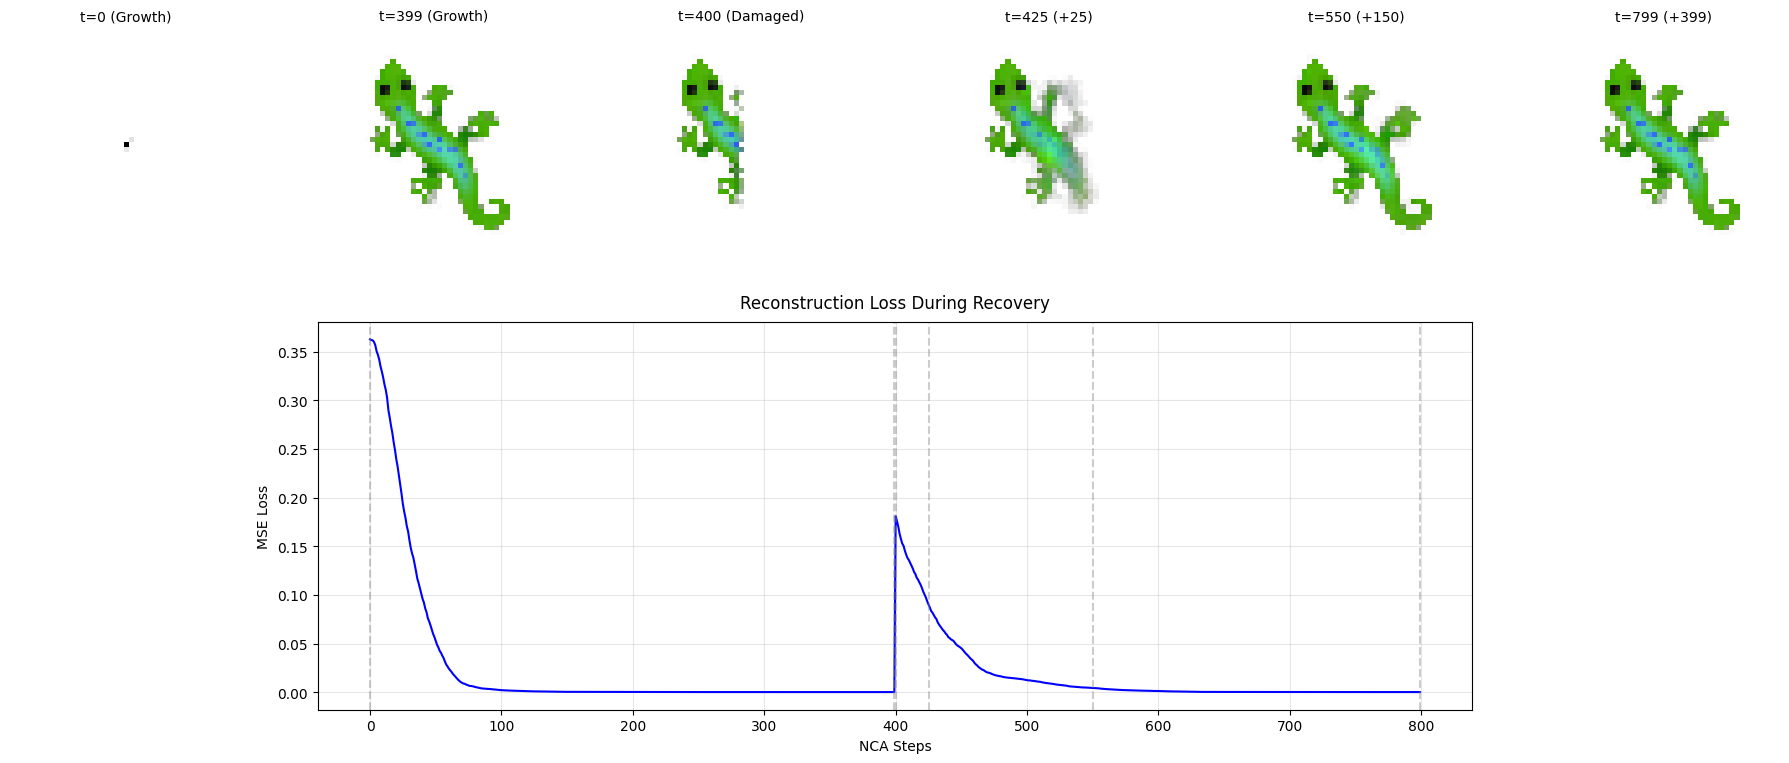

Time to recover after damage: 166 steps


In [15]:
visualize_regeneration(nca, seed, base, "right_half")

In [19]:
import pandas as pd
def measure_recovery_time_only(nca, seed, base_target, damage='right_half',
                                total_steps=800, damage_step=400,
                                circle_radius=5, device='cuda:0',
                                patience=10, delta_tol=1e-4, target_mse=0.005):
    """
    Single trial: grow from seed, damage at damage_step, track MSE only
    (no energy/drift/frames), return recovery time in steps or None.
    """
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base_target.to(device)
    live_mask = (base_target[:, 3:4] > 0.1).float()

    loss_recovery = []

    with torch.no_grad():
        for t in range(total_steps):
            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)
                damaged_mse = ((x[:, :4] - base_target) * live_mask).pow(2).sum().item() / (live_mask.sum().item()*4 + 1e-8)
                loss_recovery.append(damaged_mse)

            x = nca(x)
            diff = (x[:, :4] - base_target) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
            loss_recovery.append(current_mse)

    post_damage_mse = loss_recovery[damage_step:]
    return find_convergence_step(post_damage_mse, patience=patience, delta_tol=delta_tol, target_mse=target_mse)


def benchmark_recovery_times(nca, seed, base_target,
                              damage_types=('right_half', 'left_half', 'center_circle',
                                            'small_circle', 'random', 'cross'),
                              n_trials=10, total_steps=800, damage_step=400,
                              circle_radius=5, device='cuda:0',
                              patience=10, delta_tol=1e-4, target_mse=0.005):
    """
    Runs n_trials independent regeneration rollouts per damage type and
    returns a table (pandas DataFrame) with mean/std recovery time and
    recovery rate — no plotting.
    """
    rows = []

    for damage in damage_types:
        recovery_times = []
        n_recovered = 0

        for trial in range(n_trials):
            recovery_step = measure_recovery_time_only(
                nca, seed, base_target,
                damage=damage, total_steps=total_steps, damage_step=damage_step,
                circle_radius=circle_radius, device=device,
                patience=patience, delta_tol=delta_tol, target_mse=target_mse
            )
            if recovery_step is not None:
                recovery_times.append(recovery_step)
                n_recovered += 1

        if len(recovery_times) > 0:
            mean_time = float(np.mean(recovery_times))
            std_time = float(np.std(recovery_times))
        else:
            mean_time = float('nan')
            std_time = float('nan')

        rows.append({
            'damage_type': damage,
            'n_trials': n_trials,
            'n_recovered': n_recovered,
            'recovery_rate': n_recovered / n_trials,
            'mean_recovery_time': mean_time,
            'std_recovery_time': std_time,
        })

    return pd.DataFrame(rows)

In [17]:
def plot_attractor_phase_portrait(nca, seed, base_target, steps=300, device='cuda:0'):
    base_target = base_target.to(device)

    if isinstance(seed, np.ndarray):
        init_seed = torch.from_numpy(seed[None, ...]).to(device) if seed.ndim == 3 else torch.from_numpy(seed).to(device)
    else:
        init_seed = seed.clone().to(device)
    if init_seed.ndim == 3:
        init_seed = init_seed.unsqueeze(0)

    def get_feat(state):
        f = nca.perceive(state) if hasattr(nca, 'perceive') else state
        return f[0].cpu().numpy().flatten()

    # Grow baseline AND capture its own trajectory
    with torch.no_grad():
        x_base = init_seed.clone()
        seed_traj = [get_feat(x_base)]
        for _ in range(steps):
            x_base = nca(x_base)
            seed_traj.append(get_feat(x_base))
    seed_traj = np.array(seed_traj)

    # Perturbed starting states, all cloned from the converged x_base
    init_half         = apply_damage(x_base.clone(), damage_type='right_half', circle_radius=5)
    init_hole         = apply_damage(x_base.clone(), damage_type='center_circle', circle_radius=5)
    init_small_circle = apply_damage(x_base.clone(), damage_type='small_circle', circle_radius=5)
    init_cross         = apply_damage(x_base.clone(), damage_type='cross')
    init_memory_wipe  = x_base.clone()
    init_memory_wipe[:, 4:] = 0.0

    starting_states = [init_half, init_hole, init_small_circle, init_cross, init_memory_wipe]
    labels = ['Half Cut Damage', 'Center Hole Punch', 'Small circle mask', 'Cross section', 'Hidden Memory Reset']
    colors = ['darkred', 'orangered', 'forestgreen', 'magenta', 'purple']

    trajectories = [seed_traj]

    with torch.no_grad():
        for start_state in starting_states:
            x = start_state.clone()
            traj = [get_feat(x)]
            for t in range(steps):
                x = nca(x)
                traj.append(get_feat(x))
            trajectories.append(np.array(traj))

    labels = ['Seed Growth'] + labels
    colors = ['deepskyblue'] + colors

    with torch.no_grad():
        target_flat = get_feat(x_base)[None, :]

    all_states = np.concatenate(trajectories + [target_flat], axis=0)
    pca = PCA(n_components=2)
    pca.fit(all_states)
    target_2d = pca.transform(target_flat)

    plt.figure(figsize=(9, 7))
    for traj, color, label in zip(trajectories, colors, labels):
        traj_2d = pca.transform(traj)
        plt.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.85, linewidth=1.8, label=label)
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], color=color, marker='o', s=60)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color=color, marker='X', s=90)

    plt.scatter(target_2d[0, 0], target_2d[0, 1], color='gold', edgecolor='black',
                marker='*', s=350, zorder=5, label='Attractor in the phase portrait')

    plt.xlabel('Principal Component 1', fontsize=11)
    plt.ylabel('Principal Component 2', fontsize=11)
    plt.title('Phase Portrait: Converging Trajectories under Structural Damage', fontsize=13)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()



In [20]:
results_df = benchmark_recovery_times(nca, seed, base, n_trials=10)
results_df

,damage_type,n_trials,n_recovered,recovery_rate,mean_recovery_time,std_recovery_time
0,baseline,10,10,1.0,1.0,0.000000
1,right_half,10,10,1.0,182.6,41.888423
2,left_half,10,10,1.0,101.3,5.780138
3,center_circle,10,10,1.0,85.1,2.879236
4,small_circle,10,10,1.0,139.6,54.571421
5,random,10,10,1.0,89.1,8.324062
6,cross,10,0,0.0,NaN,NaN


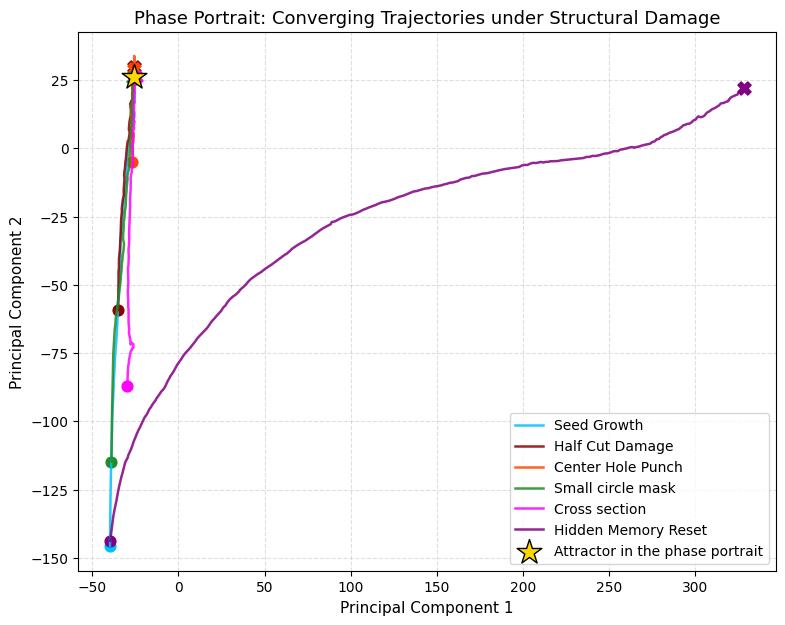

In [18]:
plot_attractor_phase_portrait(nca, seed, base)

In [ ]:
del nca
del optim
torch.cuda.empty_cache()